# VDN from scratch: a neuron that recognises before it responds

In the MLP notebooks every neuron does `h = tanh(x @ W1 + b1)`. It always answers, whatever `x` is: a real name, a typo, pure noise. <br>
In this notebook we build a different neuron, the **Vigilant Dendritic Neuron (VDN)**, one piece at a time, the same way we built the MLP. <br>
<br>
The main idea: every VDN neuron carries a small **memory of patterns** (its *keys*). Before it answers, it checks whether the input looks like something it has stored, and if not, it stays quiet. <br>
That memory turns out to be a **Hopfield network**, the same kind of memory that sits inside attention in transformers. <br>
<br>
The plan:
1. see what's missing in the MLP neuron
2. build a Hopfield memory (the classic one, then the modern one)
3. see that VDN's keys are exactly that memory
4. write memories with a Hebbian rule (no gradients), calibrate them, and add new ones when something new shows up
5. put a VDN layer together and train it
6. drop it into our makemore model and look inside

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

## 1. The MLP always answers

In [2]:
# a tiny 2-D dataset we can actually look at: two interleaving half circles ("two moons")
# (the same thing as sklearn's make_moons, written with torch so we don't need anything else)

def make_moons(n, noise=0.1, generator=None):
    n1 = n // 2
    t = torch.rand(n1, generator=generator) * torch.pi                 # angles along a half circle
    upper = torch.stack([torch.cos(t), torch.sin(t)], 1)                # the upper moon
    lower = torch.stack([1 - torch.cos(t), 0.5 - torch.sin(t)], 1)      # the lower moon: flipped and shifted
    X = torch.cat([upper, lower]) + noise * torch.randn(2 * n1, 2, generator=generator)
    Y = torch.cat([torch.zeros(n1), torch.ones(n1)]).long()             # label 0 = upper moon, 1 = lower moon
    return X, Y

g = torch.Generator().manual_seed(2147483647) # for reproducibility
X, Y = make_moons(400, generator=g)           # training set
Xte, Yte = make_moons(400, generator=g)       # test set
X.shape, Y.shape

(torch.Size([400, 2]), torch.Size([400]))

In [3]:
X[:5], Y[:5]

(tensor([[-0.6437,  0.7694],
         [ 0.3640,  0.8374],
         [ 0.7962,  0.2653],
         [-0.3717,  0.9499],
         [ 1.0186,  0.2409]]),
 tensor([0, 0, 0, 0, 0]))

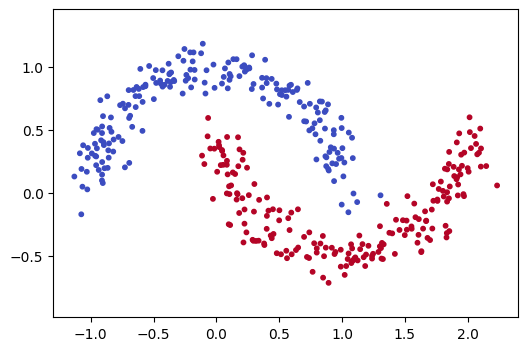

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=10)
plt.axis('equal');

In [5]:
# the MLP from the makemore notebooks, just smaller: 2 inputs -> 16 tanh neurons -> 2 outputs
g = torch.Generator().manual_seed(2147483647)
W1 = torch.randn((2, 16), generator=g)
b1 = torch.randn(16, generator=g) * 0.1
W2 = torch.randn((16, 2), generator=g) * 0.1
b2 = torch.zeros(2)
parameters = [W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters) # number of parameters in total

82

In [6]:
# full batch gradient descent, the same loop as always
for i in range(3000):
    # forward pass
    h = torch.tanh(X @ W1 + b1)   # (400, 16)
    logits = h @ W2 + b2          # (400, 2)
    loss = F.cross_entropy(logits, Y)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.5 * p.grad
    if i % 500 == 0 or i == 2999:
        print(f'{i:5d} {loss.item():.4f}')

    0 0.6953
  500 0.0412
 1000 0.0146


 1500 0.0087
 2000 0.0063
 2500 0.0050


 2999 0.0041


In [7]:
@torch.no_grad()
def mlp(x):
    return torch.tanh(x @ W1 + b1) @ W2 + b2

# accuracy on the test set
(mlp(Xte).argmax(1) == Yte).float().mean()

tensor(1.)

In [8]:
# now let's ask the MLP about points that are nowhere near the data
far = torch.tensor([[5.0, 5.0], [-4.0, 3.0], [0.5, -6.0]])
F.softmax(mlp(far), dim=1)

tensor([[1.4504e-01, 8.5496e-01],
        [1.0000e+00, 4.7569e-07],
        [8.7530e-16, 1.0000e+00]])

The MLP is almost 100% sure about points it has never seen anything like. <br>
It has no way to say "I don't know": the softmax only tells us *which class*, never *have I seen something like this*. <br>
Let's see this over the whole plane.

In [9]:
# a grid of points covering the data and a lot of empty space around it
xs = torch.linspace(-4, 5, 181)
ys = torch.linspace(-3.5, 4, 151)
gx, gy = torch.meshgrid(xs, ys, indexing='xy')
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], 1)
grid.shape

torch.Size([27331, 2])

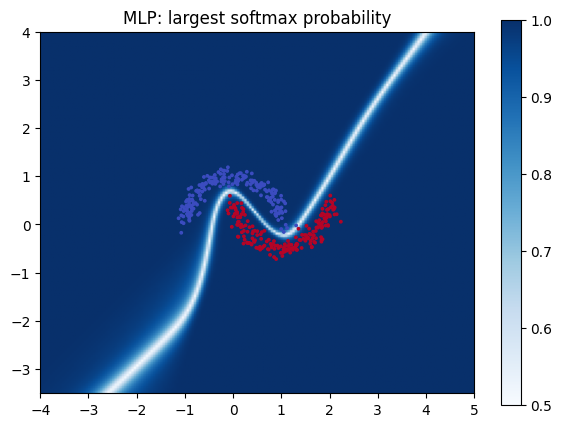

In [10]:
def show_map(values, title, vmin=0, vmax=1, cmap='Blues', ax=None):
    # draws one number per grid point as a picture, with the data on top
    ax = ax or plt.gca()
    im = ax.imshow(values.reshape(gx.shape), origin='lower', extent=(xs[0], xs[-1], ys[0], ys[-1]), cmap=cmap, vmin=vmin, vmax=vmax)
    ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=3)
    ax.set_title(title)
    return im

plt.figure(figsize=(7, 5))
im = show_map(F.softmax(mlp(grid), dim=1).max(1).values, 'MLP: largest softmax probability', vmin=0.5)
plt.colorbar(im);
# dark everywhere except a thin line along the decision boundary: the MLP is confident even in empty space

## 2. A memory of patterns: the Hopfield network

A Hopfield network (Hopfield, 1982) stores patterns in its weights with **Hebb's rule** ("neurons that fire together wire together"), and recalls a whole pattern from a damaged piece of it. <br>
Let's store 3 tiny 5x5 letters: E, M and A (as in *emma*). Every pixel is a neuron that is either on (+1) or off (-1).

In [11]:
E = '''
XXXXX
X....
XXXX.
X....
XXXXX'''

M = '''
X...X
XX.XX
X.X.X
X...X
X...X'''

A = '''
.XXX.
X...X
XXXXX
X...X
X...X'''

In [12]:
def to_vec(s):
    # 'X' -> +1 (pixel on), '.' -> -1 (pixel off), row by row into one vector of 25 numbers
    return torch.tensor([1.0 if ch == 'X' else -1.0 for row in s.strip().split('\n') for ch in row])

patterns = torch.stack([to_vec(E), to_vec(M), to_vec(A)]) # (3, 25): 3 stored patterns, 25 neurons
patterns.shape

torch.Size([3, 25])

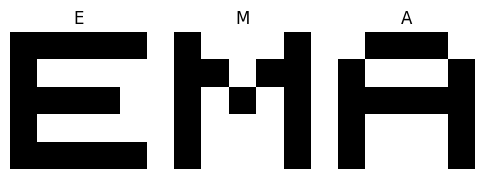

In [13]:
def show_letters(vectors, titles):
    fig, axs = plt.subplots(1, len(vectors), figsize=(2 * len(vectors), 2))
    for ax, v, t in zip(axs, vectors, titles):
        ax.imshow(v.view(5, 5), cmap='gray_r', vmin=-1, vmax=1)
        ax.set_title(t); ax.axis('off')

show_letters(patterns, ['E', 'M', 'A'])

In [14]:
# Hebb's rule: W[i, j] gets bigger when pixel i and pixel j are on (or off) together in the stored patterns
# it's just a sum of outer products, one per pattern: W = sum_p  x_p x_p^T
W = patterns.T @ patterns / 25   # (25, 3) @ (3, 25) --> (25, 25)
W.fill_diagonal_(0)              # no neuron talks to itself
W.shape

torch.Size([25, 25])

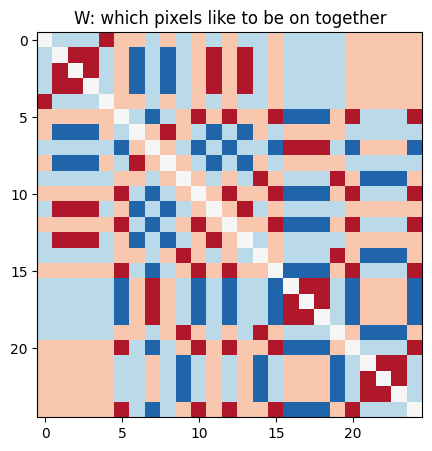

In [15]:
plt.figure(figsize=(5, 5))
plt.imshow(W, cmap='RdBu_r', vmin=-0.15, vmax=0.15)
plt.title('W: which pixels like to be on together');

In [16]:
# let's damage the A: flip 4 random pixels
g = torch.Generator().manual_seed(42)
x = patterns[2].clone()
flip = torch.randperm(25, generator=g)[:4]
x[flip] *= -1
flip

tensor([17, 12,  2,  0])

In [17]:
# recall: every neuron looks at what the others tell it (W @ x) and takes the sign, again and again
# the energy E(x) = -1/2 x.W.x can only go down; stored patterns sit at the bottom of energy valleys
def energy(x):
    return -0.5 * x @ W @ x

states = [x.clone()]
for step in range(4):
    x = torch.sign(W @ x)
    x[x == 0] = 1
    states.append(x.clone())
    print(f'step {step + 1}: energy {energy(x).item():.3f}, pixels different from A: {(x != patterns[2]).sum().item()}')

print('energy of the damaged A:', energy(states[0]).item())

step 1: energy -13.600, pixels different from A: 0
step 2: energy -13.600, pixels different from A: 0
step 3: energy -13.600, pixels different from A: 0
step 4: energy -13.600, pixels different from A: 0
energy of the damaged A: -5.760000228881836


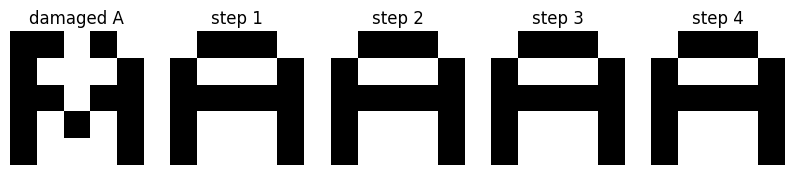

In [18]:
show_letters(states, ['damaged A', 'step 1', 'step 2', 'step 3', 'step 4'])

In [19]:
# the energy tells us how familiar a state is: low for the stored letters, higher for anything else
g = torch.Generator().manual_seed(0)
noise = torch.sign(torch.randn(25, generator=g))
print('E           ', energy(patterns[0]).item())
print('M           ', energy(patterns[1]).item())
print('A           ', energy(patterns[2]).item())
print('damaged A   ', energy(states[0]).item())
print('random noise', energy(noise).item())

E            -12.639999389648438
M            -12.0
A            -13.599998474121094
damaged A    -5.760000228881836
random noise 0.7999998331069946


### How many patterns can it hold?
The classic network breaks down when it has to hold more than about **0.14 N** random patterns (N = number of neurons). Let's check that with N = 100.

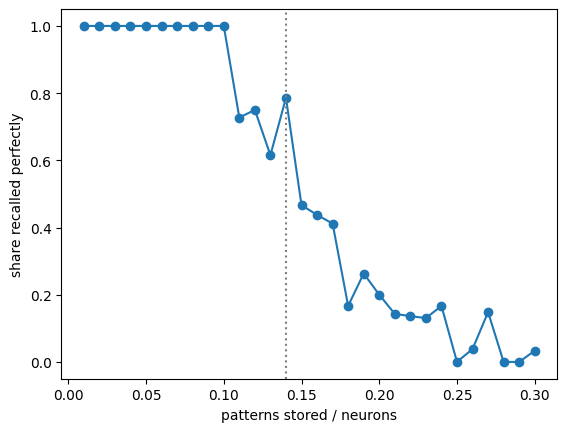

In [20]:
N = 100
g = torch.Generator().manual_seed(1)
rates = []
for P in range(1, 31):
    pats = torch.sign(torch.randn(P, N, generator=g))
    Wp = pats.T @ pats / N
    Wp.fill_diagonal_(0)
    ok = 0
    for p in pats:
        x = p.clone()
        x[torch.randperm(N, generator=g)[:10]] *= -1   # damage 10% of the pixels
        for _ in range(10):
            x = torch.sign(Wp @ x); x[x == 0] = 1
        ok += int((x == p).all())
    rates.append(ok / P)

plt.plot([P / N for P in range(1, 31)], rates, marker='o')
plt.axvline(0.14, color='gray', ls=':')
plt.xlabel('patterns stored / neurons'); plt.ylabel('share recalled perfectly');

### The modern Hopfield network
Krotov & Hopfield (2016) and Ramsauer et al. (2020, *Hopfield Networks is All You Need*) changed the energy so that the capacity becomes enormous. The recall step becomes a single line:
$$\xi_{new} = X^T \,\mathrm{softmax}(\beta\, X \xi)$$
compare the query $\xi$ with every stored pattern (rows of $X$), turn the similarities into weights with a softmax, and return the weighted average of the stored patterns. <br>
$\beta$ (the inverse temperature) decides how picky the recall is.

In [21]:
def hopfield_retrieve(patterns, query, beta):
    # one update step of the modern Hopfield network
    scores = beta * patterns @ query      # similarity of the query to every stored pattern (3,)
    weights = F.softmax(scores, dim=0)    # which pattern are we remembering?
    return weights @ patterns, weights    # the weighted average of the stored patterns (25,)

damaged = states[0]
for beta in [0.02, 0.2, 2.0]:
    out, w = hopfield_retrieve(patterns, damaged, beta)
    print(f'beta {beta:4}: weights on E, M, A = {w.numpy().round(3)}')

beta 0.02: weights on E, M, A = [0.302 0.314 0.384]
beta  0.2: weights on E, M, A = [0.074 0.11  0.816]
beta  2.0: weights on E, M, A = [0. 0. 1.]


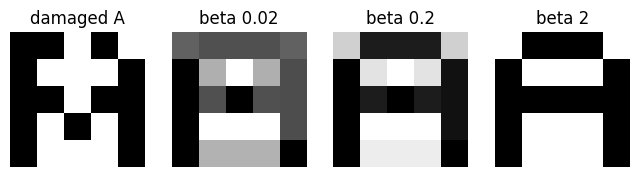

In [22]:
outs = [hopfield_retrieve(patterns, damaged, b)[0] for b in [0.02, 0.2, 2.0]]
show_letters([damaged] + outs, ['damaged A', 'beta 0.02', 'beta 0.2', 'beta 2'])
# small beta: a blurry blend of all three letters. large beta: it picks the A.

Look at that line again: `softmax(beta * patterns @ query) @ patterns`. <br>
That is **attention**: `softmax(q @ K.T) @ V` with the stored patterns as keys `K` and as values `V`. Every attention head in a transformer is a modern Hopfield memory. <br>
<br>
The modern network also has an energy, and it measures familiarity too:
$$E(\xi) = -\frac{1}{\beta}\log\sum_i e^{\beta\, x_i\cdot\xi} + \frac{1}{2}\,\xi\cdot\xi$$

In [23]:
def modern_energy(patterns, query, beta=2.0):
    return -torch.logsumexp(beta * patterns @ query, dim=0) / beta + 0.5 * query @ query

print('A           ', modern_energy(patterns, patterns[2]).item())
print('damaged A   ', modern_energy(patterns, damaged).item())
print('random noise', modern_energy(patterns, noise).item())

A            -12.5
damaged A    -4.5
random noise 7.490921974182129


## 3. VDN's keys are a Hopfield memory

A VDN neuron has **K branches**. Each branch has two things:
- a **key** $p_k$: a stored pattern in input space ("where this branch listens")
- an **answer**: its own linear function $u_k \cdot x + c_k$ ("what it says when it recognises the input")

Let's build one neuron by hand, with 3 keys in 2-D.

In [24]:
keys = torch.tensor([[-0.5, 0.5],
                     [ 1.0, 0.0],
                     [ 2.0, 0.5]])   # (K=3, 2): three stored patterns
x = torch.tensor([0.9, 0.1])         # an input close to the second key

s, T = 0.2, 0.1                      # s: the neuron's distance scale, T: temperature
d = ((x - keys) ** 2).sum(1) / s     # normalised squared distance to every key (3,)
a = F.softmax(-d / T, dim=0)         # the branches compete: the closest key wins (almost) everything
d, a

(tensor([10.6000,  0.1000,  6.8500]),
 tensor([0.0000e+00, 1.0000e+00, 4.8431e-30]))

In [25]:
# now the Hopfield version: softmax(beta * keys @ x), plus a bias for each key's size
# expand the square: |x - p|^2 = |x|^2 - 2 x.p + |p|^2
# the |x|^2 part is the same for every key, and a softmax doesn't care about something added to every entry
# so -d/T = beta * (x.p - |p|^2 / 2) + (the same number for every key), with beta = 2 / (s T)
beta = 2 / (s * T)
hop = F.softmax(beta * (keys @ x - 0.5 * (keys ** 2).sum(1)), dim=0)
print('beta =', beta)
print('VDN branch competition:', a)
print('Hopfield retrieval    :', hop)
print('same?', torch.allclose(a, hop))

beta = 99.99999999999999
VDN branch competition: tensor([0.0000e+00, 1.0000e+00, 4.8431e-30])
Hopfield retrieval    : tensor([0.0000e+00, 1.0000e+00, 4.8431e-30])
same? True


The branch competition inside a VDN neuron **is** a modern Hopfield retrieval, with $\beta = 2/(sT)$. <br>
With `T = 0.1` beta is large, so the neuron almost always retrieves the single nearest key. <br>
<br>
What does it retrieve? Not the stored pattern itself, but the **answer** that goes with it, like keys and values in attention. The value here is a small linear model, so each key brings its own local rule.

In [26]:
g = torch.Generator().manual_seed(0)
U = torch.randn((3, 2), generator=g)   # one linear answer per branch (3, 2)
c = torch.zeros(3)
answers = U @ x + c                    # what each branch would say about this x (3,)
answers

tensor([ 1.3576, -1.9041, -1.1159])

The last piece is **vigilance** (the idea comes from Grossberg's Adaptive Resonance Theory): <br>
before we trust the retrieved memory, check that the input is actually *inside* its basin. A key only counts if the input is within a radius $\rho$ of it:
$$v_k = \sigma\!\left(\frac{\rho - d_k}{w}\right) \qquad g_k = a_k\, v_k \qquad y = \sum_k g_k\,(u_k\cdot x + c_k) \qquad \text{evidence} = \sum_k g_k$$

In [27]:
rho, width = 2.0, 0.5
v = torch.sigmoid((rho - d) / width)   # inside the basin of key k? (3,)
gate = a * v                           # retrieve AND recognise
y = (gate * answers).sum()             # the neuron's output
evidence = gate.sum()                  # how much the neuron recognised x, between 0 and 1
v, gate, y, evidence

(tensor([3.3895e-08, 9.7812e-01, 6.1280e-05]),
 tensor([0.0000e+00, 9.7812e-01, 2.9678e-34]),
 tensor(-1.8624),
 tensor(0.9781))

In [28]:
# the same neuron, asked about a point far away from all three keys
def vdn_neuron(x):
    d = ((x - keys) ** 2).sum(1) / s
    a = F.softmax(-d / T, dim=0)
    v = torch.sigmoid((rho - d) / width)
    gate = a * v
    return (gate * (U @ x + c)).sum(), gate.sum()

print('near a key:', vdn_neuron(torch.tensor([0.9, 0.1])))
print('far away  :', vdn_neuron(torch.tensor([4.0, 3.0])))
# far away: evidence ~0 and the output ~0. The neuron stays quiet instead of guessing.

near a key: (tensor(-1.8624), tensor(0.9781))
far away  : (tensor(0.), tensor(0.))


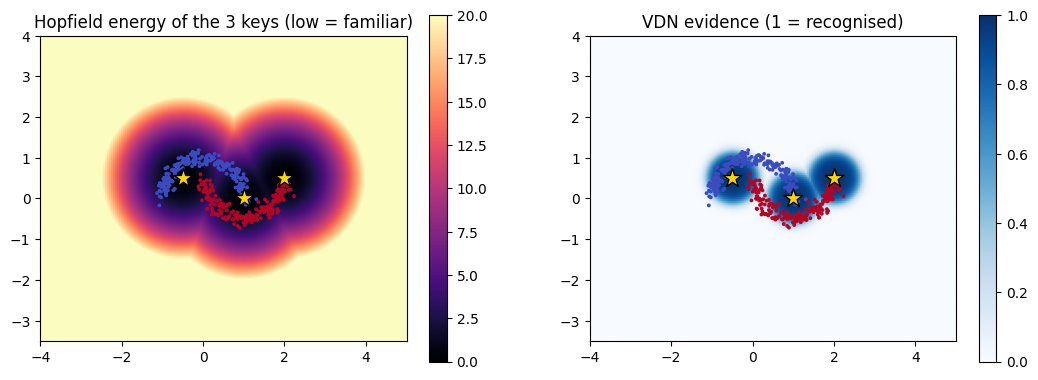

In [29]:
# let's look at the whole plane: the Hopfield energy of this memory next to the neuron's evidence
dg = ((grid[:, None, :] - keys[None]) ** 2).sum(-1) / s            # (grid points, 3)
energy_map = -T * torch.logsumexp(-dg / T, dim=1)                    # a soft minimum of the distances (in units of s)
evidence_map = (F.softmax(-dg / T, dim=1) * torch.sigmoid((rho - dg) / width)).sum(1)

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
im0 = show_map(energy_map.clamp(max=20), 'Hopfield energy of the 3 keys (low = familiar)', vmin=0, vmax=20, cmap='magma', ax=axs[0])
im1 = show_map(evidence_map, 'VDN evidence (1 = recognised)', ax=axs[1])
for ax in axs:
    ax.scatter(keys[:, 0], keys[:, 1], marker='*', s=200, c='gold', edgecolor='k')
plt.colorbar(im0, ax=axs[0]); plt.colorbar(im1, ax=axs[1]);
# the evidence is just the energy put through a threshold: recognised = inside a valley of the memory

So one VDN neuron is:

| Hopfield network / attention | VDN neuron |
|---|---|
| stored patterns (keys) | branch keys $p_k$ |
| inverse temperature $\beta$ | $2 / (s\,T)$ |
| retrieval `softmax(beta * K @ q)` | branch competition `softmax(-d / T)` |
| retrieved value | the branch's linear answer $u_k \cdot x + c_k$ |
| energy (low = familiar) | evidence (1 = recognised), via the vigilance radius $\rho$ |
| Hebbian storage | Hebbian key updates (next section) |

In an MLP a neuron is one dot product. In a VDN a neuron is a tiny associative memory that answers only about what it remembers.

## 4. Writing memories: Hebbian keys

Where do the keys come from? Not from backprop. Each key is written by a local, Hebbian rule: <br>
**every key moves to the running mean of the inputs it wins**. <br>
That's the same trick as BatchNorm's `running_mean` in makemore part 3, except that each key only averages the inputs that chose it (online k-means / competitive learning).

In [30]:
# one neuron, 8 keys, starting on 8 random training points
g = torch.Generator().manual_seed(3)
K = 8
keys = X[torch.randint(0, len(X), (K,), generator=g)].clone()
usage = torch.zeros(K)       # how many inputs each key has won so far
keys_start = keys.clone()
keys

tensor([[ 0.9368,  0.0929],
        [-0.0485,  0.3524],
        [ 0.8897,  0.1902],
        [-0.8904,  0.1954],
        [ 1.9431,  0.1466],
        [ 1.6705, -0.2218],
        [ 1.6453, -0.2855],
        [ 0.0982, -0.2506]])

In [31]:
for step in range(200):
    ix = torch.randint(0, len(X), (32,), generator=g)
    xb = X[ix]                                                   # a minibatch (32, 2)
    d = ((xb[:, None, :] - keys[None]) ** 2).sum(-1)              # (32, 8)
    winner = d.argmin(1)                                          # which key each input chose (32,)
    A = F.one_hot(winner, K).float()                              # (32, 8)
    n_new = A.sum(0)                                              # how many inputs each key won in this batch (8,)
    mean = (A.T @ xb) / n_new.clamp(min=1)[:, None]               # the mean of the inputs each key won (8, 2)
    eta = n_new / (usage + n_new).clamp(min=1)                    # a running mean: the more a key has seen, the less it moves
    keys += eta[:, None] * (mean - keys)
    usage += n_new

usage

tensor([ 543., 1132.,  985., 1086.,  649.,  565.,  541.,  899.])

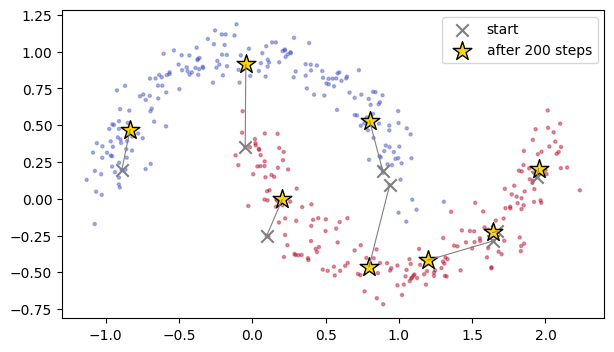

In [32]:
plt.figure(figsize=(7, 4))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=5, alpha=0.4)
plt.scatter(keys_start[:, 0], keys_start[:, 1], marker='x', s=80, c='gray', label='start')
plt.scatter(keys[:, 0], keys[:, 1], marker='*', s=200, c='gold', edgecolor='k', label='after 200 steps')
for k0, k1 in zip(keys_start, keys):
    plt.plot([k0[0], k1[0]], [k0[1], k1[1]], c='gray', lw=0.8)
plt.legend(); plt.axis('equal');
# every key slid to the middle of the patch of data it wins

### Calibration: how big is a memory's basin?
The neuron keeps two running statistics:
- `s`: the average squared distance from an input to its winning key (the neuron's scale)
- `rho`: the 95% quantile of those distances divided by `s`. By construction, about 5% of familiar inputs fall outside every basin.

In [33]:
d = ((X[:, None, :] - keys[None]) ** 2).sum(-1)    # (400, 8)
best = d.min(1).values                             # distance to the winning key (400,)
s = best.mean()
rho = torch.quantile(best / s, 0.95)
print('s   =', s.item())
print('rho =', rho.item())
print('share of the training inputs outside every basin:', ((best / s) > rho).float().mean().item())

s   = 0.07057909667491913
rho = 2.8258402347564697
share of the training inputs outside every basin: 0.05000000074505806


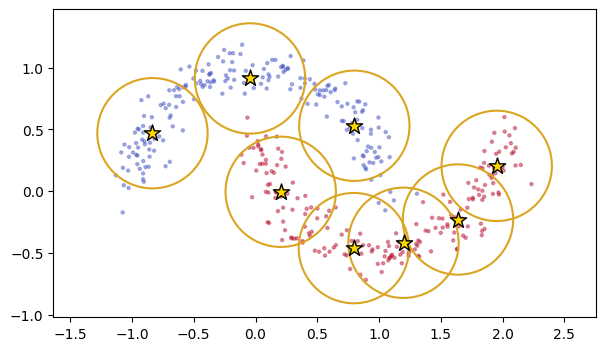

In [34]:
plt.figure(figsize=(7, 4))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=5, alpha=0.4)
for k in keys:
    plt.gca().add_patch(plt.Circle(k.numpy(), (rho * s).sqrt().item(), fill=False, color='goldenrod', lw=1.5))
plt.scatter(keys[:, 0], keys[:, 1], marker='*', s=150, c='gold', edgecolor='k')
plt.axis('equal');
# the circles are the basins: inside = recognised

### Something new shows up: recruit a new memory
A VDN neuron keeps some branches in reserve. When a batch contains clearly more unfamiliar inputs than the 5% calibration predicts, a spare branch wakes up with its key at the **centroid of the inputs that surprised the neuron**. <br>
That's how Adaptive Resonance Theory adds a category, and how a Hopfield memory gets a new slot. <br>
Let's train 4 keys on the upper moon only, and then show the neuron the lower moon.

In [35]:
upper, lower = X[Y == 0], X[Y == 1]

g = torch.Generator().manual_seed(5)
keys = torch.zeros(8, 2)
alive = torch.zeros(8, dtype=torch.bool)
keys[:4] = upper[torch.randint(0, len(upper), (4,), generator=g)]
alive[:4] = True                     # 4 keys awake, 4 kept in reserve
usage = torch.zeros(8)

def dist(x):
    d = ((x[:, None, :] - keys[None]) ** 2).sum(-1)
    return d.masked_fill(~alive[None], float('inf'))   # sleeping keys can't win

# learn the upper moon
for step in range(200):
    xb = upper[torch.randint(0, len(upper), (32,), generator=g)]
    d = dist(xb)
    A = F.one_hot(d.argmin(1), 8).float()
    n_new = A.sum(0)
    mean = (A.T @ xb) / n_new.clamp(min=1)[:, None]
    eta = n_new / (usage + n_new).clamp(min=1)
    keys += eta[:, None] * (mean - keys)
    usage += n_new

best = dist(upper).min(1).values
s = best.mean(); rho = torch.quantile(best / s, 0.95)
keys_before = keys[alive].clone()
print('unfamiliar share on the upper moon:', ((dist(upper).min(1).values / s) > rho).float().mean().item())
print('unfamiliar share on the lower moon:', ((dist(lower).min(1).values / s) > rho).float().mean().item())

unfamiliar share on the upper moon: 0.05000000074505806
unfamiliar share on the lower moon: 0.9950000047683716


In [36]:
# now stream the lower moon in, one batch at a time, and recruit when surprised
recruited = []
for step in range(40):
    xb = lower[torch.randint(0, len(lower), (32,), generator=g)]
    d = dist(xb) / s
    novel = d.min(1).values > rho                            # inputs that no key recognises
    if novel.float().mean() > 2 * (1 - 0.95) + 0.05 and (~alive).any():
        k = (~alive).nonzero()[0].item()                     # a spare branch
        keys[k] = xb[novel].mean(0)                          # its key = the centroid of the surprising inputs
        alive[k] = True; usage[k] = 1
        recruited.append((step, k))
    # and the usual Hebbian update for the inputs that were recognised
    d = dist(xb)
    A = F.one_hot(d.argmin(1), 8).float() * (~novel).float()[:, None]
    n_new = A.sum(0)
    mean = (A.T @ xb) / n_new.clamp(min=1)[:, None]
    eta = n_new / (usage + n_new).clamp(min=1)
    keys += eta[:, None] * (mean - keys)
    usage += n_new

recruited  # (step, which spare branch woke up)

[(0, 4), (1, 5), (2, 6), (3, 7)]

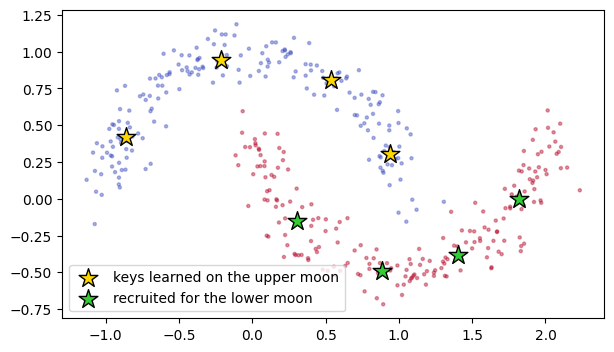

In [37]:
plt.figure(figsize=(7, 4))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=5, alpha=0.4)
plt.scatter(keys_before[:, 0], keys_before[:, 1], marker='*', s=200, c='gold', edgecolor='k', label='keys learned on the upper moon')
new = keys[alive][len(keys_before):]
plt.scatter(new[:, 0], new[:, 1], marker='*', s=200, c='limegreen', edgecolor='k', label='recruited for the lower moon')
plt.legend(loc='lower left'); plt.axis('equal');
# the old keys stayed where they were: learning the new moon didn't overwrite the old memories

## 5. A layer of VDN neurons

Now we put everything into a layer, with the same API as the `Linear` and `BatchNorm1d` classes from makemore part 3. <br>
Like BatchNorm it has **parameters** (trained with backprop: the branches' answers) and **buffers** (trained by local rules: the keys, their usage, the scale `s` and the vigilance radius `rho`). <br>
<br>
Every neuron has `K` branches; `K0` of them start awake and the rest wait in reserve. The keys are compared with the input *detached* from the graph: backprop never moves a key.

In [38]:
class VDN:
  # a layer of vigilant dendritic neurons

  def __init__(self, fan_in, fan_out, K=4, K0=None, T=0.1, width=0.5, q=0.95, momentum=0.02, refractory=20, rf=1.0):
    self.K, self.K0 = K, (K if K0 is None else K0)
    self.T, self.width, self.q, self.momentum, self.refractory = T, width, q, momentum, refractory
    self.training = True
    # parameters (trained with backprop): one linear answer per branch
    self.U = torch.randn((fan_out, K, fan_in), generator=g) / fan_in**0.5
    self.c = torch.zeros((fan_out, K))
    # buffers (trained with local rules)
    self.keys = torch.zeros((fan_out, K, fan_in))              # the stored patterns
    self.usage = torch.zeros((fan_out, K))                     # inputs won so far, per key
    self.alive = torch.zeros((fan_out, K), dtype=torch.bool)  # awake branches
    self.scale = torch.ones(fan_out)                           # s: the typical winner distance, per neuron
    self.rho = torch.full((fan_out,), 2.0)                    # the vigilance radius, in units of s
    self.cooldown = torch.zeros(fan_out, dtype=torch.long)     # steps to wait after recruiting
    self.ready = False
    self.recruits = 0
    # receptive field: each neuron compares only a random share rf of the inputs with its keys
    n_rf = max(1, round(rf * fan_in))
    self.mask = torch.zeros(fan_out, fan_in)
    for h in range(fan_out):
      self.mask[h, torch.randperm(fan_in, generator=g)[:n_rf]] = 1.0

  def distances(self, x):
    # squared distance from every input to every key of every neuron: |x|^2 - 2 x.p + |p|^2  -> (B, H, K)
    # (the middle term is the Hopfield dot product; expanding the square also saves a lot of memory)
    # (keys are kept at zero outside the neuron's receptive field, so only the inputs it sees count)
    d = ((x * x) @ self.mask.T)[:, :, None] - 2 * torch.einsum('bi,hki->bhk', x, self.keys) + (self.keys ** 2).sum(-1)[None]
    return d.clamp(min=0).masked_fill(~self.alive[None], float('inf'))

  @torch.no_grad()
  def init_from(self, x):
    # data-dependent init: every awake key starts on a real input
    H = self.keys.shape[0]
    self.keys = x[torch.randint(0, len(x), (H, self.K), generator=g)] * self.mask[:, None, :]
    self.alive[:, :self.K0] = True
    best = self.distances(x).min(-1).values
    self.scale = best.mean(0).clamp(min=1e-6)
    self.rho = torch.quantile(best / self.scale, self.q, dim=0)
    self.ready = True

  def __call__(self, x):
    xd = x.detach()                                                  # keys never see gradients
    if not self.ready:
      self.init_from(xd)
    d = self.distances(xd) / self.scale[None, :, None]               # normalised distance (B, H, K)
    a = F.softmax(-d / self.T, dim=-1)                              # Hopfield retrieval: which branch?
    v = torch.sigmoid((self.rho[None, :, None] - d) / self.width)    # vigilance: inside that branch's basin?
    gate = a * v                                                     # (B, H, K)
    answers = torch.einsum('bi,hki->bhk', x, self.U) + self.c         # every branch's linear answer (B, H, K)
    self.out = (gate * answers).sum(-1)                              # (B, H)
    self.evidence = gate.sum(-1)                                     # how much each neuron recognised x, in [0, 1] (B, H)
    if self.training:
      self.local_update(xd, d)
    return self.out

  @torch.no_grad()
  def local_update(self, x, d):
    best, kstar = d.min(-1)                                          # winning branch per neuron (B, H)
    novel = best > self.rho[None, :]                                 # inputs that no key recognises
    # 1) recruit a spare branch where a batch holds clearly more novelty than calibration predicts
    self.cooldown = (self.cooldown - 1).clamp(min=0)
    need = (novel.float().mean(0) > 2 * (1 - self.q) + 0.05) & (~self.alive).any(1) & (self.cooldown == 0)
    for h in need.nonzero().flatten().tolist():
      k = (~self.alive[h]).nonzero()[0].item()
      self.keys[h, k] = x[novel[:, h]].mean(0) * self.mask[h]        # key = centroid of the surprising inputs
      b = best[:, h].argmax()                                        # copy the answer of the branch nearest to them
      self.U.data[h, k] = self.U.data[h, kstar[b, h]]; self.c.data[h, k] = self.c.data[h, kstar[b, h]]
      self.alive[h, k] = True; self.usage[h, k] = 1; self.cooldown[h] = self.refractory; self.recruits += 1
    if need.any():
      d = self.distances(x) / self.scale[None, :, None]
      best, kstar = d.min(-1); novel = best > self.rho[None, :]
    # 2) Hebbian: every winning key moves to the running mean of the recognised inputs it wins
    A = F.one_hot(kstar, self.K).float() * (~novel).float()[..., None]      # (B, H, K)
    n_new = A.sum(0)                                                        # (H, K)
    mean = torch.einsum('bhk,bi->hki', A, x) / n_new.clamp(min=1)[..., None]
    eta = (n_new / (self.usage + n_new).clamp(min=1)).clamp(min=0.002) * (n_new > 0)
    self.keys += eta[..., None] * (mean * self.mask[:, None, :] - self.keys)
    self.usage += n_new
    # 3) calibration: running estimates of s and rho, like BatchNorm's running statistics
    raw = best * self.scale[None]
    self.scale = (1 - self.momentum) * self.scale + self.momentum * raw.mean(0).clamp(min=1e-6)
    self.rho = (1 - self.momentum) * self.rho + self.momentum * torch.quantile(raw / self.scale[None], self.q, dim=0)

  def parameters(self):
    return [self.U, self.c]


class Linear:
  # the Linear layer from makemore part 3

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

In [39]:
g = torch.Generator().manual_seed(2147483647)
layers = [VDN(2, 16, K=4, K0=2), Linear(16, 2)]   # 16 vigilant neurons, 4 branches each (2 awake, 2 in reserve)
parameters = [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters)) # number of parameters in total (the keys are buffers, not parameters)

226


In [40]:
lossi = []
for i in range(3000):
    # minibatch construct
    ix = torch.randint(0, len(X), (64,), generator=g)
    xb, yb = X[ix], Y[ix]
    # forward pass
    out = xb
    for layer in layers:
        out = layer(out)
    loss = F.cross_entropy(out, yb)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 2000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    lossi.append(loss.item())
    if i % 500 == 0 or i == 2999:
        print(f'{i:5d} {loss.item():.4f}')

print('branches recruited during training:', layers[0].recruits)

    0 0.5689


  500 0.0854


 1000 0.0290


 1500 0.0103


 2000 0.0072


 2500 0.0062


 2999 0.0553
branches recruited during training: 30


In [41]:
@torch.no_grad()
def vdn_net(x):
    for layer in layers:
        layer.training = False
    out = x
    for layer in layers:
        out = layer(out)
    for layer in layers:
        layer.training = True
    return out, layers[0].evidence.mean(1)   # logits, and how much the layer recognised each input

(vdn_net(Xte)[0].argmax(1) == Yte).float().mean()

tensor(0.9950)

In [42]:
# the same three far-away points as before
logits, ev = vdn_net(far)
print('softmax :', F.softmax(logits, dim=1))
print('evidence:', ev)
print('MLP softmax for comparison:', F.softmax(mlp(far), dim=1))

softmax : tensor([[0.4728, 0.5272],
        [0.4728, 0.5272],
        [0.4728, 0.5272]])
evidence: tensor([0., 0., 0.])
MLP softmax for comparison: tensor([[1.4504e-01, 8.5496e-01],
        [1.0000e+00, 4.7569e-07],
        [8.7530e-16, 1.0000e+00]])


Far from the data the VDN neurons go quiet (evidence close to 0), so the output falls back to the bias and the softmax becomes unsure. <br>
The network now has two separate signals: **what is it** (the softmax) and **have I seen something like this** (the evidence).

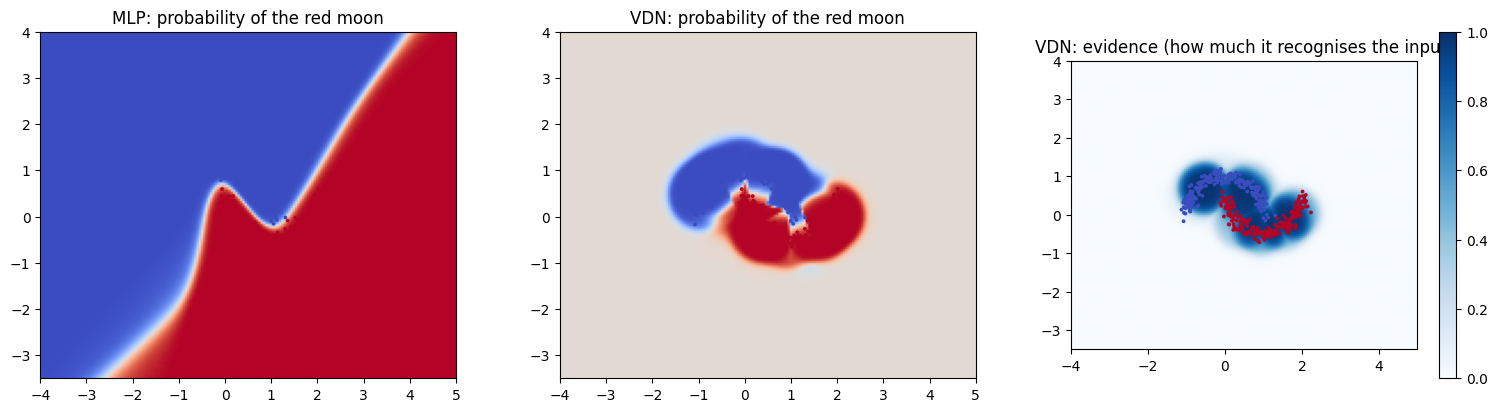

In [43]:
logits_g, ev_g = vdn_net(grid)
fig, axs = plt.subplots(1, 3, figsize=(19, 4.5))
show_map(F.softmax(mlp(grid), dim=1)[:, 1], 'MLP: probability of the red moon', cmap='coolwarm', ax=axs[0])
show_map(F.softmax(logits_g, dim=1)[:, 1], 'VDN: probability of the red moon', cmap='coolwarm', ax=axs[1])
im = show_map(ev_g, 'VDN: evidence (how much it recognises the input)', ax=axs[2])
plt.colorbar(im, ax=axs[2]);

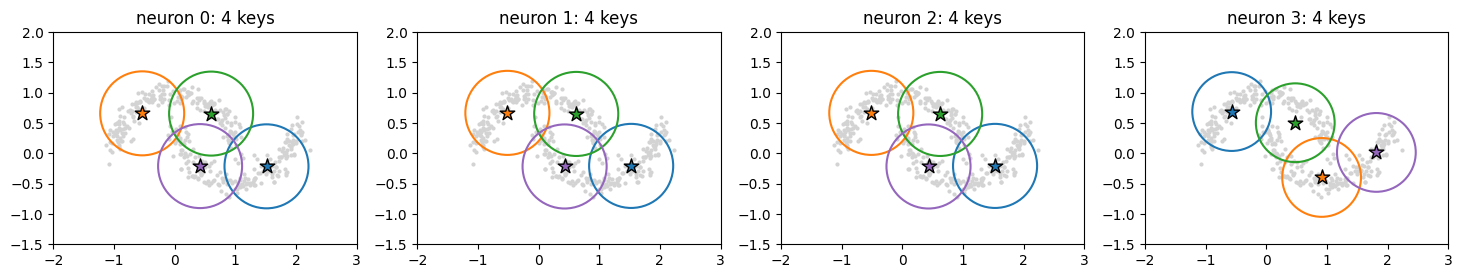

In [44]:
# the keys of the first 4 neurons, with their basins
L = layers[0]
fig, axs = plt.subplots(1, 4, figsize=(18, 3.6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
for h, ax in enumerate(axs):
    ax.scatter(X[:, 0], X[:, 1], c='lightgray', s=4)
    for k in L.alive[h].nonzero().flatten().tolist():
        p = L.keys[h, k]
        ax.add_patch(plt.Circle(p.numpy(), (L.rho[h] * L.scale[h]).sqrt().item(), fill=False, color=colors[k], lw=1.5))
        ax.scatter(p[0], p[1], marker='*', s=120, color=colors[k], edgecolor='k')
    ax.set_title(f'neuron {h}: {int(L.alive[h].sum())} keys'); ax.set_aspect('equal'); ax.set_xlim(-2, 3); ax.set_ylim(-1.5, 2)

## 6. VDN inside makemore

Same data and same setup as makemore part 3: 3 characters of context, 10-dimensional embeddings. We swap the tanh hidden layer for a VDN layer. <br>
The keys live in the space of the concatenated embeddings (30 numbers), so each key is a remembered **3-character context**.

In [45]:
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
len(words), vocab_size

(32033, 27)

In [46]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
X_train, Y_train = build_dataset(words[:n1])
X_dev, Y_dev = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


### The reference: the MLP from part 3

In [47]:
n_embd = 10   # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0
mlp_parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in mlp_parameters)) # number of parameters in total
for p in mlp_parameters:
  p.requires_grad = True

11897


In [48]:
max_steps = 30000
batch_size = 32
mlp_lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_train[ix], Y_train[ix] # batch X,Y
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  h = torch.tanh(embcat @ W1 + b1) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  # backward pass
  for p in mlp_parameters:
    p.grad = None
  loss.backward()
  # update
  lr = 0.1 if i < 20000 else 0.01 # step learning rate decay
  for p in mlp_parameters:
    p.data += -lr * p.grad
  # track stats
  if i % 5000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  mlp_lossi.append(loss.log10().item())

      0/  30000: 3.3179


   5000/  30000: 2.2234


  10000/  30000: 2.1910


  15000/  30000: 1.9153


  20000/  30000: 2.3270


  25000/  30000: 2.2530


### A first VDN model
embeddings -> 100 VDN neurons, 4 branches each (2 awake, 2 in reserve) -> output layer

In [49]:
def make_vdn_model(K, K0, rf):
  g.manual_seed(2147483647) # for reproducibility
  C = torch.randn((vocab_size, n_embd), generator=g)
  layers = [VDN(n_embd * block_size, 100, K=K, K0=K0, rf=rf), Linear(100, vocab_size)]
  with torch.no_grad():
    layers[-1].weight *= 0.1 # make the output layer less confident at the start, like in part 3
  params = [C] + [p for layer in layers for p in layer.parameters()]
  for p in params:
    p.requires_grad = True
  return C, layers, params

def train_vdn(C, layers, params):
  lossi = []
  for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix] # batch X,Y
    # forward pass
    x = C[Xb].view(batch_size, -1) # embed and concatenate
    for layer in layers:
      x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function
    # backward pass
    for p in params:
      p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 20000 else 0.01 # step learning rate decay
    for p in params:
      p.data += -lr * p.grad
    # track stats
    if i % 5000 == 0:
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
  return lossi

C_a, layers_a, params_a = make_vdn_model(K=4, K0=2, rf=1.0)
print(sum(p.nelement() for p in params_a)) # number of parameters in total (keys not counted: they're buffers)
lossi_a = train_vdn(C_a, layers_a, params_a)
print('branches recruited:', layers_a[0].recruits)

15397
      0/  30000: 3.3227


   5000/  30000: 2.5024


  10000/  30000: 2.1323


  15000/  30000: 2.2726


  20000/  30000: 2.3790


  25000/  30000: 2.1209


branches recruited: 200


### Let's look inside: what did the neurons memorise?
Each key is a point in the 30-dimensional space of 3 concatenated embeddings. To read it, find the training contexts closest to it: that's the memory stored in that key.

In [50]:
contexts, context_counts = X_train.unique(dim=0, return_counts=True) # every distinct 3-character context in the training set
len(contexts)

5438

In [51]:
@torch.no_grad()
def nearest_contexts(C, L, h, k, n=5):
  # the n training contexts closest to key k of neuron h, measured only on the inputs neuron h sees
  e = C[contexts].view(len(contexts), -1)
  d = (((e - L.keys[h, k]) ** 2) * L.mask[h]).sum(1)
  top = d.argsort()[:n]
  return ' '.join(''.join(itos[i] for i in contexts[t].tolist()) for t in top)

def show_memories(C, L, neurons=range(4)):
  for h in neurons:
    print(f'neuron {h}:')
    for k in L.alive[h].nonzero().flatten().tolist():
      print(f'    key {k} (won {int(L.usage[h, k]):6d} inputs): {nearest_contexts(C, L, h, k)}')

show_memories(C_a, layers_a[0])

neuron 0:
    key 0 (won 260149 inputs): ... ..z ..d ..x ..r
    key 1 (won 228040 inputs): azz aze adz eze zze
    key 2 (won 255446 inputs): zaz zuz zad zed zan
    key 3 (won 153415 inputs): .za zza .zu .ze ..a
neuron 1:
    key 0 (won 278734 inputs): ... ..z ..d ..x ..e
    key 1 (won 291592 inputs): zaz zed zad zuz zen
    key 2 (won 223222 inputs): zza zze .za .ze zzu
    key 3 (won 103349 inputs): zzl zel zal zaz zul
neuron 2:
    key 0 (won 235363 inputs): azz aze adz eze zze
    key 1 (won 253286 inputs): ... ..z ..d ..x ..r
    key 2 (won 220889 inputs): zaz zuz zad zed zan
    key 3 (won 187769 inputs): .za zza .zu .ze ..a
neuron 3:
    key 0 (won 291592 inputs): zaz zed zad zuz zen
    key 1 (won 278734 inputs): ... ..z ..d ..x ..e
    key 2 (won 223222 inputs): zza zze .za .ze zzu
    key 3 (won 103349 inputs): zzl zel zal zaz zul


Look at the lists: the neurons learned (almost) **the same memories**. Some neurons hold exactly the same keys as others. <br>
That's because they all look at the same 30 numbers, and a running mean of the same data ends up in the same place for everyone (it's k-means, and k-means on the same data finds the same clusters). 100 neurons, but only a handful of different memories. <br>
<br>
The fix, like a real dendrite that only touches some of the axons around it: a **receptive field**. Each neuron compares only a random third of the 30 inputs with its keys, so different neurons remember different aspects of the context. Let's also give each neuron more room: 8 branches, 4 awake.

In [52]:
C_v, vdn_layers, vdn_parameters = make_vdn_model(K=8, K0=4, rf=0.34)
print(sum(p.nelement() for p in vdn_parameters)) # number of parameters in total
vdn_lossi = train_vdn(C_v, vdn_layers, vdn_parameters)
print('branches recruited:', vdn_layers[0].recruits)

27797
      0/  30000: 3.3053


   5000/  30000: 2.2162


  10000/  30000: 2.0408


  15000/  30000: 2.0687


  20000/  30000: 2.2293


  25000/  30000: 1.8786


branches recruited: 400


In [53]:
show_memories(C_v, vdn_layers[0])

neuron 0:
    key 0 (won  93785 inputs): zde zia ida zka zie
    key 1 (won 252479 inputs): ... ..y .ny .ey ..i
    key 2 (won 104704 inputs): asi osi aii oii aui
    key 3 (won  91519 inputs): ..r .er zer .nz ..z
    key 4 (won 104260 inputs): lay qay iay lan zay
    key 5 (won  80350 inputs): ysi rsi yse rse ysa
    key 6 (won  90712 inputs): rri ori .ri zri rre
    key 7 (won  87187 inputs): zuc zec .uc .ec ..c
neuron 1:
    key 0 (won 277721 inputs): ... ..a ..n ..y ..z
    key 1 (won  77434 inputs): lyn lsy lya ley lsa
    key 2 (won  85555 inputs): .sl nsl .sk nsk ..l
    key 3 (won 108536 inputs): nan aan adn naa nda
    key 4 (won 111460 inputs): nde nae nse ndi nne
    key 5 (won 125789 inputs): .sw ..w nsb .aw naw
    key 6 (won  39163 inputs): non .on nor son ron
    key 7 (won  69588 inputs): iay isy idy iae ian
neuron 2:
    key 0 (won 144501 inputs): gly .ly aly yly xly
    key 1 (won  57905 inputs): .el ael gel nel zel
    key 2 (won 160914 inputs): naa naw aas nas .aa
 

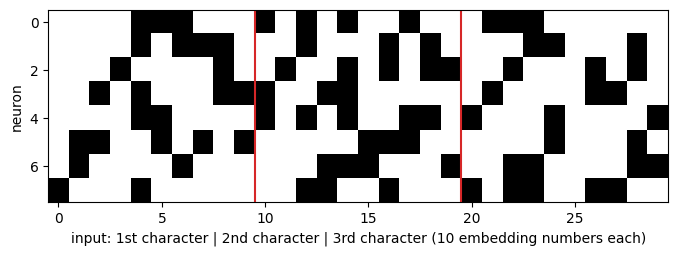

In [54]:
# which of the 3 character positions (and which embedding numbers) does each of the first neurons see?
plt.figure(figsize=(8, 2.5))
plt.imshow(vdn_layers[0].mask[:8], cmap='Greys', aspect='auto')
plt.axvline(9.5, color='tab:red'); plt.axvline(19.5, color='tab:red')
plt.xlabel('input: 1st character | 2nd character | 3rd character (10 embedding numbers each)'); plt.ylabel('neuron');

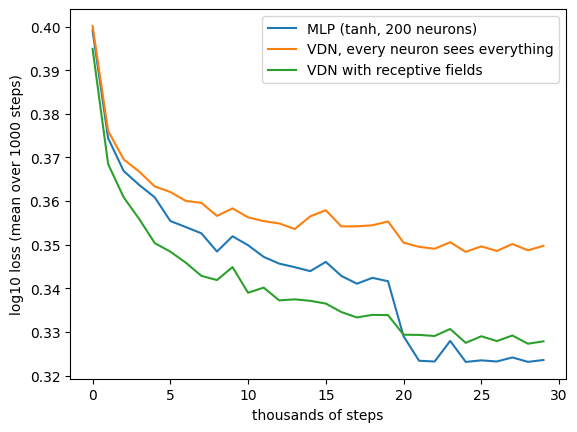

In [55]:
plt.plot(torch.tensor(mlp_lossi).view(-1, 1000).mean(1), label='MLP (tanh, 200 neurons)')
plt.plot(torch.tensor(lossi_a).view(-1, 1000).mean(1), label='VDN, every neuron sees everything')
plt.plot(torch.tensor(vdn_lossi).view(-1, 1000).mean(1), label='VDN with receptive fields')
plt.ylabel('log10 loss (mean over 1000 steps)'); plt.xlabel('thousands of steps'); plt.legend();

In [56]:
@torch.no_grad() # this decorator disables gradient tracking
def vdn_forward(C, layers, x):
  # evaluation mode, in chunks: every input meets every key of every neuron
  for layer in layers:
    layer.training = False
  outs, evs = [], []
  for i in range(0, len(x), 20000):
    out = C[x[i:i+20000]].view(-1, n_embd * block_size)
    for layer in layers:
      out = layer(out)
    outs.append(out); evs.append(layers[0].evidence.mean(1))
  for layer in layers:
    layer.training = True
  return torch.cat(outs), torch.cat(evs)

@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (X_train, Y_train),
    'val': (X_dev, Y_dev),
    'test': (X_test, Y_test),
  }[split]
  mlp_loss = F.cross_entropy(torch.tanh(C[x].view(len(x), -1) @ W1 + b1) @ W2 + b2, y)
  vdn_a = F.cross_entropy(vdn_forward(C_a, layers_a, x)[0], y)
  vdn_rf = F.cross_entropy(vdn_forward(C_v, vdn_layers, x)[0], y)
  print(f'{split:5s}  MLP {mlp_loss.item():.4f}   VDN (no receptive fields) {vdn_a.item():.4f}   VDN {vdn_rf.item():.4f}')

split_loss('train')
split_loss('val')

train  MLP 2.1139   VDN (no receptive fields) 2.2409   VDN 2.1360


val    MLP 2.1457   VDN (no receptive fields) 2.2448   VDN 2.1658


In [57]:
# sample from the VDN model
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
  out = []
  context = [0] * block_size # initialize with all ...
  while True:
    logits, _ = vdn_forward(C_v, vdn_layers, torch.tensor([context]))
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))

carmah.
ambrileigh.
mri.
reety.
salaysie.
rahnel.
delyah.
jareei.
nellara.
chaiiv.
kaleigh.
ham.
joce.
quinthonoi.
rai.
adiquinathonielryxi.
jacee.
dus.
bred.
ediia.


### Does the VDN recognise a name?
Remember makemore part 1: `jq` never appears in the data, so the bigram model gave `andrejq` an infinite loss. <br>
The VDN layer has its own opinion about every context, the evidence: how much its neurons recognise those 3 characters. Let's read a few words character by character.

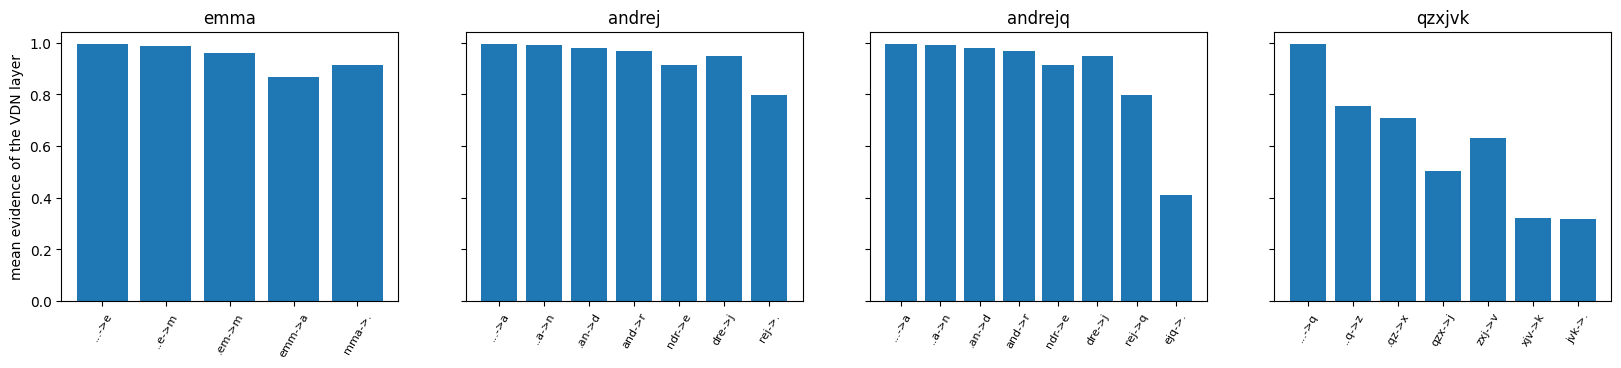

In [58]:
@torch.no_grad()
def context_evidence(word):
  # evidence of the VDN layer for every context while reading the word
  contexts_w, labels = [], []
  context = [0] * block_size
  for ch in word + '.':
    contexts_w.append(context)
    labels.append(''.join(itos[i] for i in context) + '->' + ch)
    context = context[1:] + [stoi[ch]]
  _, ev = vdn_forward(C_v, vdn_layers, torch.tensor(contexts_w))
  return labels, ev

fig, axs = plt.subplots(1, 4, figsize=(20, 3.5), sharey=True)
for ax, w in zip(axs, ['emma', 'andrej', 'andrejq', 'qzxjvk']):
  labels, ev = context_evidence(w)
  ax.bar(range(len(ev)), ev, color='tab:blue')
  ax.set_xticks(range(len(ev))); ax.set_xticklabels(labels, rotation=60, fontsize=8)
  ax.set_title(w)
axs[0].set_ylabel('mean evidence of the VDN layer');

In [59]:
# now many words at once: real names from the validation set vs strings of random letters
g = torch.Generator().manual_seed(7)
real = words[n1:n2][:1000]
junk = [''.join(chars[i] for i in torch.randint(0, 26, (int(torch.randint(4, 8, (1,), generator=g)),), generator=g)) for _ in range(1000)]
junk[:10]

['mredfpf',
 'jkfs',
 'kuyyt',
 'gqztsq',
 'bgirkqf',
 'oqnlc',
 'tqgcneu',
 'sjpj',
 'ihaxwgo',
 'vmscvha']

In [60]:
def build_quiet(words):
  # build_dataset without the print
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      X.append(context); Y.append(stoi[ch]); context = context[1:] + [stoi[ch]]
  return torch.tensor(X), torch.tensor(Y)

@torch.no_grad()
def word_scores(ws):
  # for every word: the average evidence while reading it, and the model's own loss on it
  evs, nlls = [], []
  for w in ws:
    x, y = build_quiet([w])
    logits, ev = vdn_forward(C_v, vdn_layers, x)
    evs.append(ev.mean().item()); nlls.append(F.cross_entropy(logits, y).item())
  return torch.tensor(evs), torch.tensor(nlls)

ev_real, nll_real = word_scores(real)
ev_junk, nll_junk = word_scores(junk)

AUROC with the VDN evidence       : 0.900862991809845
AUROC with the model's own loss   : 0.993179976940155


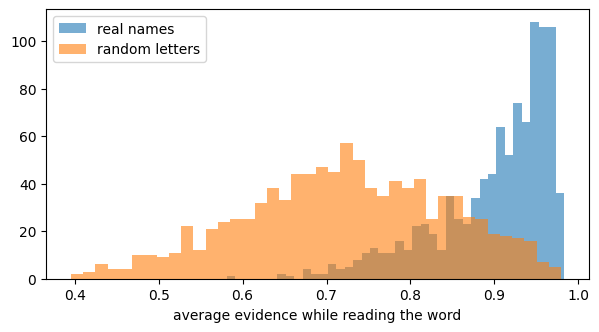

In [61]:
def auroc(pos, neg):
  # the chance that a random real word scores higher than a random junk word (1 = perfect, 0.5 = no clue)
  return ((pos[:, None] > neg[None]).float().mean() + 0.5 * (pos[:, None] == neg[None]).float().mean()).item()

plt.figure(figsize=(7, 3.5))
plt.hist(ev_real.tolist(), 40, alpha=0.6, label='real names')
plt.hist(ev_junk.tolist(), 40, alpha=0.6, label='random letters')
plt.xlabel('average evidence while reading the word'); plt.legend()
print('AUROC with the VDN evidence       :', auroc(ev_real, ev_junk))
print("AUROC with the model's own loss   :", auroc(-nll_real, -nll_junk))

The evidence tells real names from random letters most of the time, without ever being trained to. <br>
But here a language model already has a better familiarity signal: its own loss, because it's a model of the whole string. <br>
The evidence matters most where a model has *no* probability of its input: in a classifier. That's where, with a thickness per input direction added to each key, VDN told Fashion-MNIST apart from MNIST at 0.995 AUROC from its own signal.

## Summary
- An MLP neuron is one dot product: it answers everything, with the same confidence near the data and far from it.
- A VDN neuron is a tiny **associative memory**: its keys are stored patterns, the competition between branches is a **modern Hopfield retrieval** with $\beta = 2/(sT)$, and what it retrieves is the matching branch's linear answer (a key/value memory, like one attention head).
- **Vigilance** asks whether the input sits inside a memory's basin, the Hopfield energy put through a threshold. The sum of the gates is the neuron's **evidence**: "I recognise this".
- Keys are written by a **Hebbian running mean** (no gradients), the basin size is **calibrated** like BatchNorm's running statistics, and **new memories are recruited** when something unfamiliar keeps showing up, without overwriting the old ones.
- Neurons that all see the same inputs memorise the same things; **receptive fields** (each neuron sees a random part of the input) make their memories different.

What the Hopfield view suggests trying next:
- learn $\beta$ (the temperature) per neuron instead of fixing it
- run more than one retrieval step (a real Hopfield network iterates until it settles)
- use the energy itself as the evidence signal, and give each key its own shape (a Mahalanobis energy) to recognise unfamiliar inputs even better
- the known weakness: answers are local around stored patterns, so functions where neighbours disagree (like parity) are hard for it

References: Hopfield (1982); Krotov & Hopfield, *Dense Associative Memory* (2016); Ramsauer et al., *Hopfield Networks is All You Need* (2020); Carpenter & Grossberg, Adaptive Resonance Theory (vigilance).